# XGBoost

Para aplicar un XGBoost a una serie temporal, tenemos que cambiar nuestro enfoque. A diferencia de las LSTMs (que leen secuencias temporales tridimensionales) o GARCH (que tiene la autorregresión integrada en su fórmula), XGBoost necesita que la variable tiempo se convierta en columnas estáticas. Esto significa que debemos hacer un fuerte *Feature Engineering* creando "Lags" (rezagos). Le daremos a XGBoost la volatilidad de ayer, la de hace dos días y la de hace una semana como columnas separadas, para que el árbol de decisión pueda encontrar las reglas lógicas (*"Si la volatilidad de ayer fue mayor a X y el RSI es menor a Y, entonces la volatilidad de hoy será Z"*).

# 1. Carga de Datos y Feature Engineering (Creación de Lags)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv('..\data\processed\spy_processed.csv', index_col='Date', parse_dates=True)

# Creación de Variables Rezagadas (Lags)
# Le damos al modelo "memoria" convirtiendo el pasado en columnas
lags_vol = [1, 2, 3, 5, 21] # Volatilidad de ayer, hace 2, 3, 5 días (una semana) y 21 días (un mes)
lags_ret = [1, 5]           # Retornos de ayer y hace una semana

for lag in lags_vol:
    df[f'Vol_Lag_{lag}'] = df['Realized_Vol'].shift(lag)
    
for lag in lags_ret:
    df[f'Ret_Lag_{lag}'] = df['Log_Returns'].shift(lag)

# También mantenemos nuestros indicadores técnicos
features = [col for col in df.columns if col not in ['Price', 'Log_Returns', 'Realized_Vol', 'Squared_Returns']]
target = 'Realized_Vol'

# Al hacer shifts (rezagos), creamos valores nulos (NaN) al principio del dataset. Los eliminamos.
df.dropna(inplace=True)

print("\nFeatures que usará XGBoost:")
print(features)


Features que usará XGBoost:
['EMA_12', 'EMA_26', 'MACD', 'RSI', 'Vol_Lag_1', 'Vol_Lag_2', 'Vol_Lag_3', 'Vol_Lag_5', 'Vol_Lag_21', 'Ret_Lag_1', 'Ret_Lag_5']


# División de Datos (Previniendo Data Leakage)

Con XGBoost no es estrictamente necesario escalar los datos (MinMaxScaler o StandardScaler). Los árboles de decisión basan sus divisiones (splits) en el orden de los valores, no en su magnitud absoluta, por lo que son inmunes a variables con diferentes escalas.\
Lo que sí es vital para no tener Leakage es hacer el split cronológico exacto que hicimos en los otros modelos.

In [ ]:
# Split Train/Test (Misma fecha que GARCH y Redes Neuronales)
split_date = '2024-01-01'

train_data = df[:split_date]
test_data = df[split_date:]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print(f"\nTamaño Entrenamiento: {len(X_train)} días")
print(f"Tamaño Test: {len(X_test)} días")


Tamaño Entrenamiento: 5995 días
Tamaño Test: 572 días


# 3. Definición y Entrenamiento del Modelo XGBoost

Usaremos ``XGBRegressor``. Los hiperparámetros (ajustes de configuración que definimos antes de que el modelo empiece a aprender de los datos) clave aquí son n_estimators (cuántos árboles construir), learning_rate (cuán rápido aprende) y max_depth (cuán profundos son los árboles; mantenerlo bajo, como 3 o 4, previene el sobreajuste masivo al que son propensos los árboles en finanzas).

In [ ]:
# Configuración del modelo XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,        
    learning_rate=0.05,      
    max_depth=4,             
    subsample=0.8,           
    colsample_bytree=0.8,    
    objective='reg:squarederror', 
    random_state=42,
    early_stopping_rounds=20 
)

# Entrenamiento
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False            # Solo dejamos los datos de evaluación y el verbose aquí
)


Entrenando XGBoost...
¡Entrenamiento completado!


# 4. Predicción y Evaluación Visual

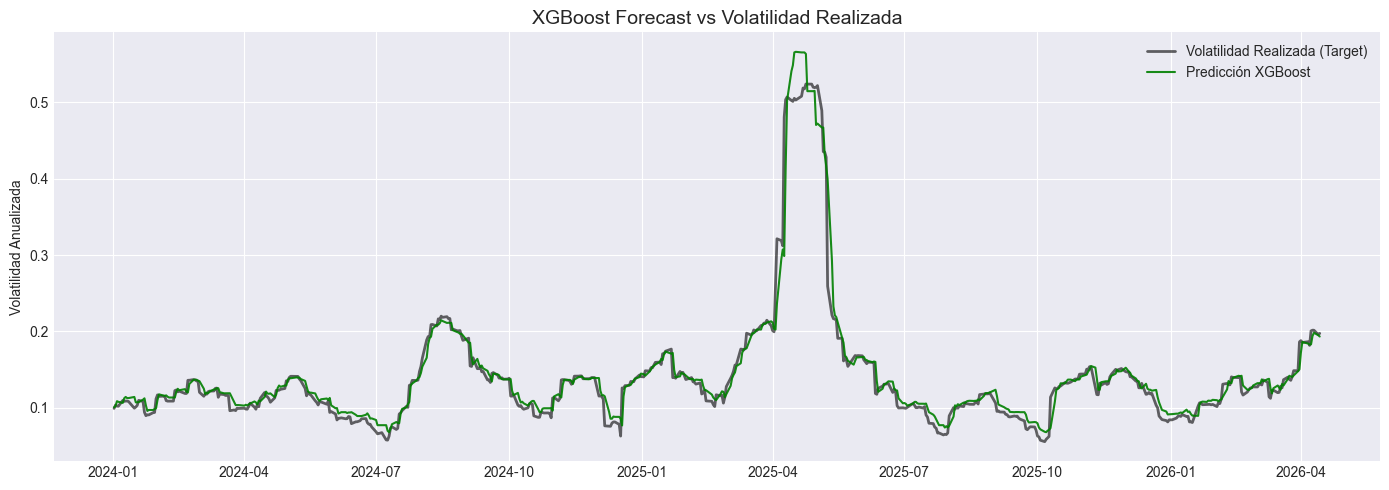

In [ ]:
# Generar predicciones en el set de prueba
xgb_predictions = xgb_model.predict(X_test)

# Guardamos en un DataFrame para poder exportarlo e integrarlo en el Notebook 4
df_xgb_results = pd.DataFrame(index=X_test.index)
df_xgb_results['XGBoost_Pred'] = xgb_predictions

# Gráfico de Predicción vs Realidad
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Volatilidad Realizada (Target)', color='black', alpha=0.6, linewidth=2)
plt.plot(df_xgb_results.index, df_xgb_results['XGBoost_Pred'], label='Predicción XGBoost', color='green', alpha=0.9)

plt.title('XGBoost Forecast vs Volatilidad Realizada', fontsize=14)
plt.ylabel('Volatilidad Anualizada')
plt.legend()
plt.tight_layout()
plt.show()

# Exportar resultados
df_xgb_results.to_csv(r'..\data\processed\xgboost_predictions.csv')

# 5. Feature Importance

Esta es la razón principal por la que a los fondos cuantitativos les encantan estos modelos. Podemos extraer un gráfico exacto de cuánto peso le dio el algoritmo a cada variable matemática para tomar sus decisiones.

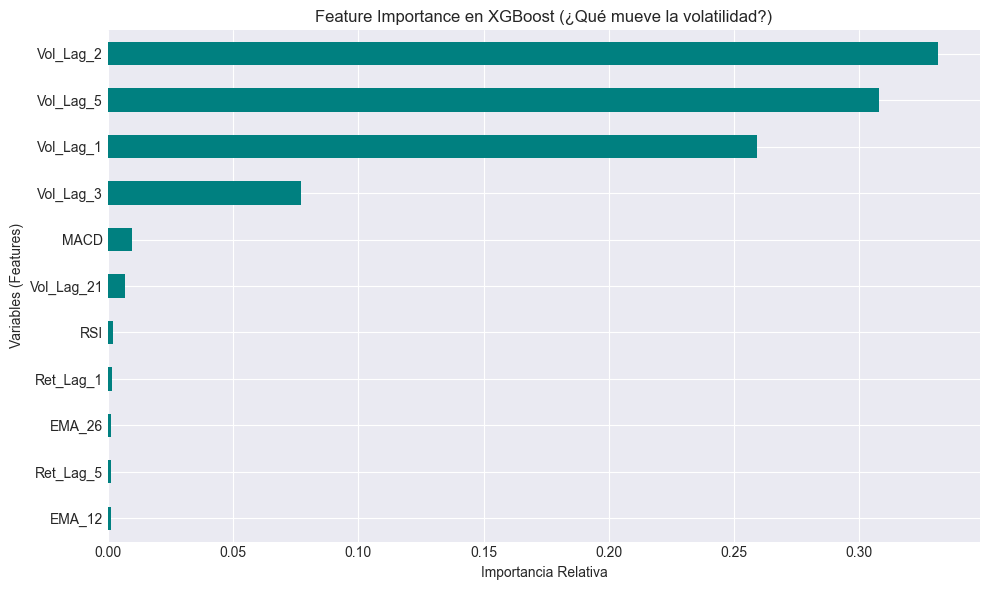

In [ ]:
# Analizando la Importancia de las Variables
plt.figure(figsize=(10, 6))

# Extraemos la importancia (usamos el criterio 'weight' o 'gain')
importancias = pd.Series(xgb_model.feature_importances_, index=features)
importancias_ordenadas = importancias.sort_values(ascending=True)

importancias_ordenadas.plot(kind='barh', color='teal')
plt.title('Feature Importance en XGBoost (¿Qué mueve la volatilidad?)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables (Features)')
plt.tight_layout()
plt.show()


Como vemos, la volatilidad tiene una memoria enorme: las variables que representan la volatilidad pasada (Vola_Lag) dominan el modelo. Esto confirma el fenómeno financiero *Volatility Clustering* (es decir, la volatilidad se agrupa).\
Además, la volatilidad de hae 2 días y la de hace 5 (una semana de traiding) tienen mayor poder predictivo que la volatilidad de ayer.\
Por último, observamos que los indicadores técnicos no tienen mucha utilidad cuando se trata de predecir la magnitud de la volatilidad con este modelo.